# Phân tích và dự đoán rủi ro tài chính cá nhân

---


## Mục tiêu nghiên cứu

**Mục tiêu tổng quát:**  
    Phát triển một mô hình học máy có khả năng phân loại rủi ro tài chính (Risk Rating) dựa trên các đặc điểm nhân khẩu học và đặc điểm tài chính của cá nhân.  
**Mục tiêu cụ thể:**  
1. Nâng cao hiệu suất mô hình trên tất cả ba lớp (High, Medium, Low), đặc biệt tập trung vào việc cải thiện Recall và Precision cho các lớp thiểu số (High, Medium).
2. Nghiên cứu và áp dụng các kỹ thuật xử lý mất cân bằng lớp tiên tiến để đạt được sự cân bằng tốt hơn và cải thiện hiệu suất trên các lớp thiểu số.
3. So sánh và lựa chọn mô hình dựa trên các chỉ số đánh giá phù hợp cho dữ liệu mất cân bằng (như F1-Score macro/weighted, Recall cho lớp thiểu số) để đảm bảo mô hình cân bằng hiệu suất trên tất cả các lớp.
4. Xác định các đặc trưng quan trọng nhất ảnh hưởng đến việc phân loại rủi ro, đặc biệt là đối với lớp High Risk, để hiểu rõ hơn về mô hình và dữ liệu.

---


## 1. Thu thập và tải dữ liệu

### 1.1. Nguồn dữ liệu

Bộ dữ liệu `financial_risk_assessment.csv` cung cấp thông tin chi tiết về hồ sơ tài chính cá nhân nhằm đánh giá rủi ro tài chính được lấy từ trang web Kaggle.com theo địa chỉ trang web cụ thể sau "https://www.kaggle.com/datasets/preethamgouda/financial-risk/data"

### 1.2. Ý nghĩa bộ dữ liệu

#### Đọc và kiểm tra kích thước, thông tin tổng quan

In [1]:
import pandas as pd
import numpy as np

In [2]:
# Đọc file, đồng thời đổi những ô chứa  giá trị "Non-binary" thành "NaN"
file = 'financial_risk_assessment.csv'
df = pd.read_csv(file, na_values = 'Non-binary')

In [3]:
# Xem trước bộ dữ liệu
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    15000 non-null  int64  
 1   Gender                 9941 non-null   object 
 2   Education Level        15000 non-null  object 
 3   Marital Status         15000 non-null  object 
 4   Income                 12750 non-null  float64
 5   Credit Score           12750 non-null  float64
 6   Loan Amount            12750 non-null  float64
 7   Loan Purpose           15000 non-null  object 
 8   Employment Status      15000 non-null  object 
 9   Years at Current Job   15000 non-null  int64  
 10  Payment History        15000 non-null  object 
 11  Debt-to-Income Ratio   15000 non-null  float64
 12  Assets Value           12750 non-null  float64
 13  Number of Dependents   12750 non-null  float64
 14  City                   15000 non-null  object 
 15  St

#### Ý nghĩa các cột

| Tên cột    |  Mô tả |
|------------|--------|
| `Age`      | Tuổi tác |
| `Gender`     | Giới tính |
| `Education Level`   | Trình độ học vấn |
| `Marital Status`     | Tình trạng hôn nhân hiện tại |
| `Income`     | Thu nhập hàng năm (USD) |
| `Credit Score`      | Điểm tín dụng |
| `Loan Amount`     | Số tiền vay |
| `Loan Purpose`    | Mục đích vay |
| `Employment Status`   | Tình trạng việc làm |
| `Years at Current Job`| Số năm kinh nghiệm của công việc hiện tại |
| `Payment History`      | Lịch sử thanh toán |
| `Debt-to-Income Ratio`     | Tỉ lệ Nợ trên Thu nhập |
| `Assets Value`    | Tổng giá trị tài sản sở hữu |
| `Number of Dependents`   | Số người phụ thuộc |
| `City`| Thành phố |
| `State`      | Tiểu bang |
| `Country`     | Quốc gia |
| `Previous Defaults`    | Số lần bị vỡ nợ trước đây |
| `Marital Status Change`   | Số lần thay đổi tình trạng hôn nhân (Số lần ly hôn) |
| `Risk Rating`| Rủi ro tài chính (cột mục tiêu) |


---

## 2. Làm sạch và Tiền xử lý dữ liệu

#### Kiểm tra sơ bộ dữ liệu

In [4]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import KNNImputer
import seaborn as sns
import matplotlib.pyplot as plt

Phân phối của Risk Rating:
Risk Rating
Low       60.0
Medium    30.0
High      10.0
Name: proportion, dtype: float64


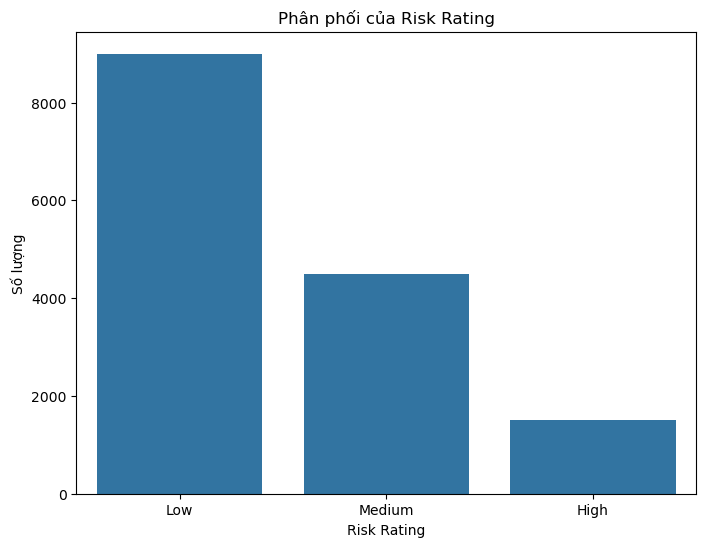

In [5]:
# Kiểm tra phân phối của Risk Rating
print("Phân phối của Risk Rating:")
print(df['Risk Rating'].value_counts(normalize=True) * 100)

# Vẽ biểu đồ phân phối
fig = plt.figure(figsize=(8, 6))
sns.countplot(x='Risk Rating', data=df, order=['Low', 'Medium', 'High'])
plt.title('Phân phối của Risk Rating')
plt.xlabel('Risk Rating')
plt.ylabel('Số lượng')
plt.show()

# Lưu biểu đồ
fig.savefig('Kiểm tra phân phối của Risk Rating', dpi=400)

* Sự mất cân bằng lớp trong cột `Risk Rating`:
    * Lớp `Low` chiếm tỷ lệ lớn nhất (60%).
    * Lớp `Medium` chiếm tỷ lệ trung bình (30%).
    * Lớp `High` chiếm tỷ lệ nhỏ nhất (10%).

* Sự chênh lệch đáng kể về số lượng giữa các lớp (đặc biệt là lớp `High` so với `Low`) cho thấy đây là một bài toán phân loại với dữ liệu không cân bằng lớp.

* Vì dữ liệu bị mất cân bằng lớp, việc huấn luyện mô hình phân loại trực tiếp trên tập dữ liệu này có thể dẫn đến mô hình ưu tiên dự đoán lớp chiếm đa số (`Low`) và hoạt động kém hiệu quả đối với các lớp thiểu số (`Medium`, `High`).

* Do đó, phải áp dụng các kỹ thuật xử lý dữ liệu không cân bằng lớp như `SMOTE` (Synthetic Minority Over-sampling Technique). `SMOTE` hoạt động bằng cách tạo ra các mẫu tổng hợp cho các lớp thiểu số, giúp cân bằng lại phân phối lớp trong tập dữ liệu huấn luyện. Điều này giúp mô hình học tốt hơn các đặc trưng của các lớp thiểu số và cải thiện hiệu suất dự đoán tổng thể, đặc biệt là đối với các lớp `Medium` và `High` rủi ro.

In [6]:
# Thống kê các cột số
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,15000.0,43.452667,14.910732,18.000000,31.000000,43.000000,56.000000,69.00000
Income,12750.0,69933.398510,29163.626207,20005.000000,44281.500000,69773.000000,95922.750000,119997.00000
Credit Score,12750.0,699.109098,57.229465,600.000000,650.000000,699.000000,748.000000,799.00000
Loan Amount,12750.0,27450.010902,12949.940135,5000.000000,16352.500000,27544.000000,38547.500000,49998.00000
Years at Current Job,15000.0,9.476267,5.769707,0.000000,4.000000,9.000000,15.000000,19.00000
Debt-to-Income Ratio,15000.0,0.350438,0.143919,0.100004,0.227386,0.350754,0.476095,0.59997
Assets Value,12750.0,159741.497176,80298.115832,20055.000000,90635.250000,159362.000000,228707.000000,299999.00000
Number of Dependents,12750.0,2.026510,1.411300,0.000000,1.000000,2.000000,3.000000,4.00000
Previous Defaults,12750.0,1.992471,1.416909,0.000000,1.000000,2.000000,3.000000,4.00000
Marital Status Change,15000.0,0.998467,0.813782,0.000000,0.000000,1.000000,2.000000,2.00000


In [7]:
# Thống kê các cột danh mục
df.describe(include=[object])

,Gender,Education Level,Marital Status,Loan Purpose,Employment Status,Payment History,City,State,Country,Risk Rating
count,9941,15000,15000,15000,15000,15000,15000,15000,15000,15000
unique,2,4,4,4,3,4,10614,59,243,3
top,Female,Bachelor's,Widowed,Personal,Employed,Good,East Michael,CO,Congo,Low
freq,4990,3829,3893,3771,5026,3822,19,282,124,9000


In [8]:
# Kiểm tra dữ liệu trùng lắp
df.duplicated().sum()

0

**Bộ dữ liệu không có dữ liệu trùng lắp.**

In [9]:
# Kiểm tra dữ liệu thiếu
print('Số lượng dữ liệu thiếu của từng cột')
print(df.isnull().sum())

# Phân tích dữ liệu thiếu
print("\nTỷ lệ dữ liệu thiếu theo cột:")
print(df.isnull().mean() * 100)

Số lượng dữ liệu thiếu của từng cột
Age                         0
Gender                   5059
Education Level             0
Marital Status              0
Income                   2250
Credit Score             2250
Loan Amount              2250
Loan Purpose                0
Employment Status           0
Years at Current Job        0
Payment History             0
Debt-to-Income Ratio        0
Assets Value             2250
Number of Dependents     2250
City                        0
State                       0
Country                     0
Previous Defaults        2250
Marital Status Change       0
Risk Rating                 0
dtype: int64

Tỷ lệ dữ liệu thiếu theo cột:
Age                       0.000000
Gender                   33.726667
Education Level           0.000000
Marital Status            0.000000
Income                   15.000000
Credit Score             15.000000
Loan Amount              15.000000
Loan Purpose              0.000000
Employment Status         0.000000
Years

**Thống kê lại các cột có dữ liệu thiếu:**
| Tên cột | Số lượng cột thiếu | Tỷ lệ |
|---------|--------------------|-------|
| `Gender` | 5059 | 33.73% |
| `Income` | 2250 | 15.00% |
| `Credit Score` | 2250 | 15.00% |
| `Loan Amount` | 2250 | 15.00% |
| `Assets Value` | 2250 | 15.00% |
| `Number of Dependents` | 2250 | 15.00% |
| `Previous Defaults` | 2250 | 15.00% |

**Qua kết quả kiểm tra sơ bộ, chúng ta có thể thấy bộ dữ liệu hiện tại chưa được làm sạch nên cần được xử lý các dữ liệu thiếu, dữ liệu ngoại lai và dữ liệu mất cân bằng.**

#### 2.1. Làm sạch dữ liệu

In [10]:
# Tạo thêm cột "Loan-Amount-to-Assets-Value Ratio" (Tỉ lệ Vay trên Tài sản)
df['Loan-Amount-to-Assets-Value Ratio'] = (df['Loan Amount'] / df['Assets Value']).round(2)

# Tạo thêm cột "Loan-Amount-to-Income Ratio" (Tỉ lệ Vay trên Thu nhập)
df['Loan-Amount-to-Income Ratio'] = (df['Loan Amount'] / df['Income']).round(2)


* Thêm hai cột  `Loan-Amount-to-Assets-Value Ratio` và `Loan-Amount-to-Income Ratio` để phục vụ cho việc phân tích và xây dựng mô hình Machine Learning.

In [11]:
# Sử dụng mode (giá trị phổ biến nhất) để điền giá trị bị thiếu
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
print("Số giá trị bị thiếu trong Gender sau khi xử lý:", df['Gender'].isna().sum())

Số giá trị bị thiếu trong Gender sau khi xử lý: 0


* Vì cột `Gender` là cột dữ liệu danh mục nên không thể áp dụng các cách điền dữ liệu thiếu như `mean` hay `median` (dùng cho cột số) mà phải sử dụng phương thức `mode` để điền dữ liệu thiếu bằng nhóm phổ biến trong dữ liệu hiện có, giúp giữ được tính toàn vẹn của dữ liệu mà không cần loại bỏ cột.

In [12]:
# Lọc ra list các cột số
num_cols = df.select_dtypes(include=[np.number, 'float']).columns.tolist()
selected_data = df[num_cols]

# Điền giá trị thiếu cho cột số bằng KNN Imputer
knn_imputer = KNNImputer()
imputed_data = knn_imputer.fit_transform(selected_data)
imputed_df = pd.DataFrame(imputed_data, columns=num_cols)

* Sử dụng `KNN Imputer` để điền giá trị thiếu cho các cột số vì nó là một phương pháp mạnh mẽ hơn so với việc chỉ sử dụng giá trị trung bình (mean) hoặc trung vị (median).

In [13]:
# Chọn ra các cột danh mục
categorical_df = df[['Gender', 'Education Level', 'Marital Status', 'Loan Purpose',
                    'Employment Status', 'Payment History', 'Risk Rating']]
# Kết hợp lại với các cột danh mục và Risk Rating
df = pd.concat([imputed_df, categorical_df], axis=1)

* Lí do không chọn các cột `City`, `State`, `Country` để phân tích và xây dựng mô hình phân loại rủi ro tài chính vì chúng ít hoặc không ảnh hưởng trực tiếp đến khả năng trả nợ hoặc mức độ rủi ro tài chính cá nhân của khách hàng so với các yếu tố khác.

In [14]:
# Xoá biến Target khỏi list cột số (nếu có)
target = 'Risk Rating'
if target in num_cols:
    num_cols.remove(target)

print("Các cột số phải xử lí outliers:", num_cols)

# Tiến hành xử lý outliers
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

print("\nĐã xử lý outliers cho cột số.")

Các cột số phải xử lí outliers: ['Age', 'Income', 'Credit Score', 'Loan Amount', 'Years at Current Job', 'Debt-to-Income Ratio', 'Assets Value', 'Number of Dependents', 'Previous Defaults', 'Marital Status Change', 'Loan-Amount-to-Assets-Value Ratio', 'Loan-Amount-to-Income Ratio']

Đã xử lý outliers cho cột số.


* Phương pháp chặn (capping) bằng IQR giúp giới hạn ảnh hưởng của outliers bằng cách thay thế các giá trị cực đoan bằng ngưỡng trên/dưới thay vì loại bỏ chúng hoàn toàn.

In [15]:
# Kiểm tra lại còn dữ liệu thiếu không
print("\nCác giá trị thiếu sau khi xử lý:")
print(df.isnull().sum())


Các giá trị thiếu sau khi xử lý:
Age                                  0
Income                               0
Credit Score                         0
Loan Amount                          0
Years at Current Job                 0
Debt-to-Income Ratio                 0
Assets Value                         0
Number of Dependents                 0
Previous Defaults                    0
Marital Status Change                0
Loan-Amount-to-Assets-Value Ratio    0
Loan-Amount-to-Income Ratio          0
Gender                               0
Education Level                      0
Marital Status                       0
Loan Purpose                         0
Employment Status                    0
Payment History                      0
Risk Rating                          0
dtype: int64


In [16]:
# Lưu bộ dữ liệu đã làm sạch
df.to_csv('Cleaned_financial_risk_assessment.csv', index = False)
print("Đã lưu file dưới tên 'Cleaned_financial_risk_assessment.csv'")

Đã lưu file dưới tên 'Cleaned_financial_risk_assessment.csv'


#### 2.2. Tiền xử lý dữ liệu

**Tiền xử lý dữ liệu để phục vụ cho bước xây dựng mô hình**

In [17]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import pandas as pd
import pickle

In [18]:
# Đọc file đã làm sạch ở bước trước
df = pd.read_csv('Cleaned_financial_risk_assessment.csv')

In [19]:
# Lọc ra list các cột danh mục trừ cột mục tiêu Risk Rating
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
# Loại cột mục tiêu ra khỏi list (nếu có)
if 'Risk Rating' in categorical_features:
    categorical_features.remove('Risk Rating')

print("Các cột danh mục cần One-Hot Encoding:", categorical_features)

Các cột danh mục cần One-Hot Encoding: ['Gender', 'Education Level', 'Marital Status', 'Loan Purpose', 'Employment Status', 'Payment History']


In [20]:
# Áp dụng One-Hot Encoding cho các cột danh mục
df = pd.get_dummies(df, columns=categorical_features, drop_first=True)

# Mã hóa cột mục tiêu Risk Rating bằng LabelEncoder
le_target = LabelEncoder()
df['Risk Rating Encoded'] = le_target.fit_transform(df['Risk Rating'])

# Lưu le_target để sử dụng sau này trong hàm dự đoán
with open('le_target.pkl', 'wb') as f:
    pickle.dump(le_target, f)

print("DataFrame sau khi One-Hot Encoding và Label Encoding:")
display(df.head())

DataFrame sau khi One-Hot Encoding và Label Encoding:


,Age,Income,Credit Score,Loan Amount,Years at Current Job,Debt-to-Income Ratio,Assets Value,Number of Dependents,Previous Defaults,Marital Status Change,...,Marital Status_Widowed,Loan Purpose_Business,Loan Purpose_Home,Loan Purpose_Personal,Employment Status_Self-employed,Employment Status_Unemployed,Payment History_Fair,Payment History_Good,Payment History_Poor,Risk Rating Encoded
0,49.0,72799.0,688.0,45713.0,19.0,0.154313,120228.0,0.0,2.0,2.0,...,False,True,False,False,False,True,False,False,True,1
1,57.0,86989.6,690.0,33835.0,6.0,0.148920,55849.0,0.0,3.0,2.0,...,True,False,False,False,False,False,True,False,False,2
2,21.0,55687.0,600.0,36623.0,8.0,0.362398,180700.0,3.0,3.0,2.0,...,False,False,True,False,False,False,True,False,False,2
3,59.0,26508.0,622.0,26541.0,2.0,0.454964,157319.0,3.0,4.0,2.0,...,False,False,False,True,False,True,False,False,False,2
4,25.0,49427.0,766.0,36528.0,10.0,0.143242,287140.0,2.2,3.0,1.0,...,True,False,False,True,False,True,True,False,False,1


* Sử dụng `One-Hot Encoding` để tránh tạo ra mối quan hệ thứ tự giả giữa các danh mục còn lại, nhưng với cột mục tiêu, `LabelEncoder` là phương pháp tiêu chuẩn.

* Sử dụng `LabelEncoder` để mã hóa cột `Risk Rating` vì nó là cột mục tiêu (target variable) cho bài toán phân loại này, nó là một công cụ đơn giản và hiệu quả để chuyển đổi các nhãn phân loại dạng văn bản (như `Low`, `Medium`, `High`) thành các giá trị số nguyên duy nhất (ví dụ: 0, 1, 2).

In [21]:
# --- Bắt đầu phần chia dữ liệu ---

# Xác định lại selected_features bao gồm cả các cột One-Hot Encoded mới
# Bắt đầu với các cột số đã được chuẩn hóa hoặc điền thiếu
selected_features =  ['Age', 'Income', 'Credit Score', 'Loan Amount', 'Debt-to-Income Ratio',
                      'Assets Value', 'Marital Status Change', 'Number of Dependents',
                      'Years at Current Job', 'Previous Defaults',
                      'Loan-Amount-to-Assets-Value Ratio', 'Loan-Amount-to-Income Ratio']
# Thêm tất cả các cột đã được One-Hot Encoding vào selected_features
# Lấy danh sách tất cả các cột trong df trừ cột Risk Rating gốc và cột Risk Rating Encoded mới
all_feature_cols = [col for col in df.columns if col not in ['Risk Rating', 'Risk Rating Encoded']]
selected_features = all_feature_cols # Use all processed columns as features

target = 'Risk Rating Encoded'

X = df[selected_features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("\nData splitting complete with capped outliers and One-Hot Encoded features.")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

# --- Kết thúc phần chia dữ liệu ---


Data splitting complete with capped outliers and One-Hot Encoded features.
X_train shape: (10500, 27)
X_test shape: (4500, 27)
y_train shape: (10500,)
y_test shape: (4500,)


* Bước chia dữ liệu này để tạo ra một tập dữ liệu độc lập để đánh giá hiệu suất thực sự của mô hình trên dữ liệu mới, giúp phát hiện và tránh overfitting, từ đó xây dựng được mô hình đáng tin cậy hơn.

In [22]:
# Danh sách các cột số cần chuẩn hóa
numerical_cols = ['Age', 'Income', 'Credit Score', 'Loan Amount', 'Debt-to-Income Ratio',
                  'Assets Value', 'Number of Dependents', 'Previous Defaults']

# Tạo đối tượng StandardScaler
scaler = StandardScaler()

# Chuẩn hóa các cột số
df[numerical_cols] = scaler.fit_transform(df[numerical_cols].fillna(df[numerical_cols].mean()))

# Lưu scaler để sử dụng sau này trong hàm dự đoán
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Dữ liệu số đã được chuẩn hóa.")

Dữ liệu số đã được chuẩn hóa.


* `StandardScaler` được sử dụng để chuẩn hóa các cột số, đưa chúng về cùng một thang đo (mean=0, std=1). Điều này rất quan trọng cho các mô hình học máy như `best_voting_clf`.
`scaler` được lưu vào tệp `scaler.pkl` để sử dụng lại khi tiền xử lý dữ liệu mới trong hàm dự đoán.

In [23]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("\nSMOTE applied.")
print("Original dataset shape:", y_train.shape)
print("Resampled dataset shape:", y_train_resampled.shape)
print("Distribution of target variable before SMOTE:\n", y_train.value_counts())
print("Distribution of target variable after SMOTE:\n", y_train_resampled.value_counts())



SMOTE applied.
Original dataset shape: (10500,)
Resampled dataset shape: (18924,)
Distribution of target variable before SMOTE:
 Risk Rating Encoded
1    6308
2    3162
0    1030
Name: count, dtype: int64
Distribution of target variable after SMOTE:
 Risk Rating Encoded
1    6308
2    6308
0    6308
Name: count, dtype: int64


* Tiến hành áp dụng `SMOTE` vì bộ dữ liệu đang bị mất cân bằng lớp (class imbalance) trong cột mục tiêu `Risk Rating`, điều này có thể dẫn đến Accuracy cao giả tạo, hiệu suất kém trên các lớp quan trọng.

* `SMOTE` giải quyết vấn đề này bằng cách tạo ra các mẫu tổng hợp cho các lớp thiểu số (`Medium`, `High`) trong tập dữ liệu huấn luyện. Nó không sao chép các mẫu hiện có mà tạo ra các mẫu mới dựa trên các mẫu lân cận trong không gian đặc trưng. Điều này giúp cân bằng lại phân phối lớp, cải thiện khả năng học của mô hình trên lớp thiểu số và nâng cao hiệu suất tổng thể.

In [24]:
# Kiểm tra lại bộ dữ liệu sau khi tiền xử lý
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 29 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                15000 non-null  float64
 1   Income                             15000 non-null  float64
 2   Credit Score                       15000 non-null  float64
 3   Loan Amount                        15000 non-null  float64
 4   Years at Current Job               15000 non-null  float64
 5   Debt-to-Income Ratio               15000 non-null  float64
 6   Assets Value                       15000 non-null  float64
 7   Number of Dependents               15000 non-null  float64
 8   Previous Defaults                  15000 non-null  float64
 9   Marital Status Change              15000 non-null  float64
 10  Loan-Amount-to-Assets-Value Ratio  15000 non-null  float64
 11  Loan-Amount-to-Income Ratio        15000 non-null  flo

In [25]:
# Lưu bộ dữ liệu đã mã hoá
df.to_csv('Coded_financial_risk_assessment.csv', index = False)
print("Đã lưu file dưới tên 'Coded_financial_risk_assessment.csv'")

Đã lưu file dưới tên 'Coded_financial_risk_assessment.csv'


---

## 3. Trực quan hóa dữ liệu

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [27]:
# Đọc file để trực quan hoá
df = pd.read_csv('Cleaned_financial_risk_assessment.csv')

* Sử dụng tệp `Cleaned_financial_risk_assessment.csv` cho trực quan hóa để đảm bảo các biểu đồ dễ đọc và dễ hiểu bằng cách hiển thị các nhãn gốc, và điều này không ảnh hưởng đến tính chính xác của việc trực quan hóa vì cấu trúc dữ liệu cơ bản vẫn được giữ nguyên. Tệp `Coded_financial_risk_assessment.csv` chủ yếu được sử dụng cho mục đích huấn luyện mô hình học máy vì các thuật toán yêu cầu đầu vào dạng số.

### 3.1. Phân phối Risk Rating

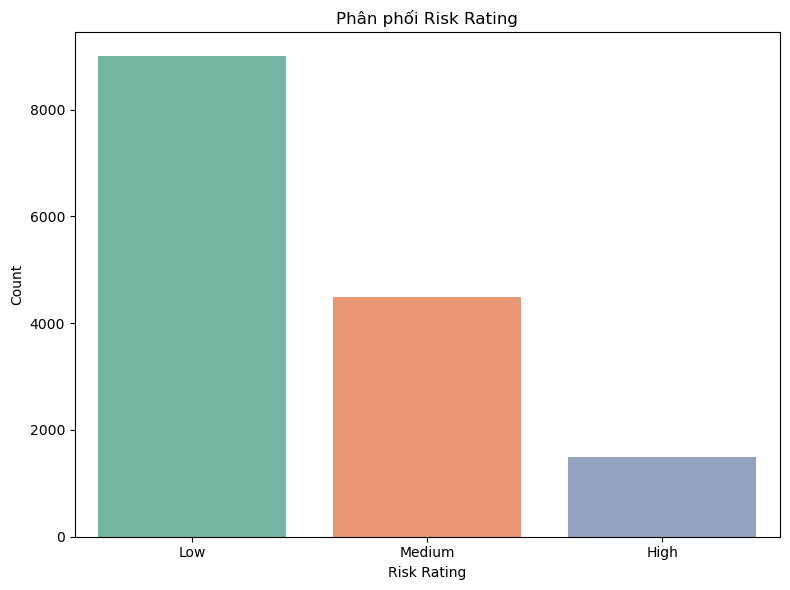

In [28]:
# Tạo biểu đồ countplot
fig1 = plt.figure(figsize=(8, 6))
sns.countplot(x='Risk Rating', data=df, palette='Set2', hue='Risk Rating')
plt.title('Phân phối Risk Rating')
plt.xlabel('Risk Rating')
plt.ylabel('Count')

# Hiển thi biểu đồ
plt.tight_layout()
plt.show()

# Lưu biều đồ
fig1.savefig('Phân phối Risk Rating', dpi=400)


**Insights**
1. Biểu đồ countplot thể hiện phân phối Risk Rating.
2. Hầu hết các trường hợp (khoảng 8000) có mức rủi ro thấp (Low).
3. Mức rủi ro trung bình (Medium) chiếm khoảng 4000 trường hợp.
4. Mức rủi ro cao (High) có số lượng thấp nhất, khoảng 2000 trường hợp.
5. Phân bố rủi ro nghiêng mạnh về mức thấp, cho thấy đa số trường hợp an toàn.
6. Sự khác biệt lớn giữa rủi ro thấp và cao, với rủi ro cao chỉ bằng 1/4 rủi ro thấp.
7. Mức rủi ro trung bình nằm giữa, nhưng vẫn thấp hơn đáng kể so với rủi ro thấp.

### 3.2. Phân phối cột danh mục theo Risk Rating

In [29]:
# Chọn ra các cột danh mục để trực quan
his_cols = ['Gender', 'Education Level', 'Marital Status', 'Employment Status',
       'Payment History', 'Loan Purpose']


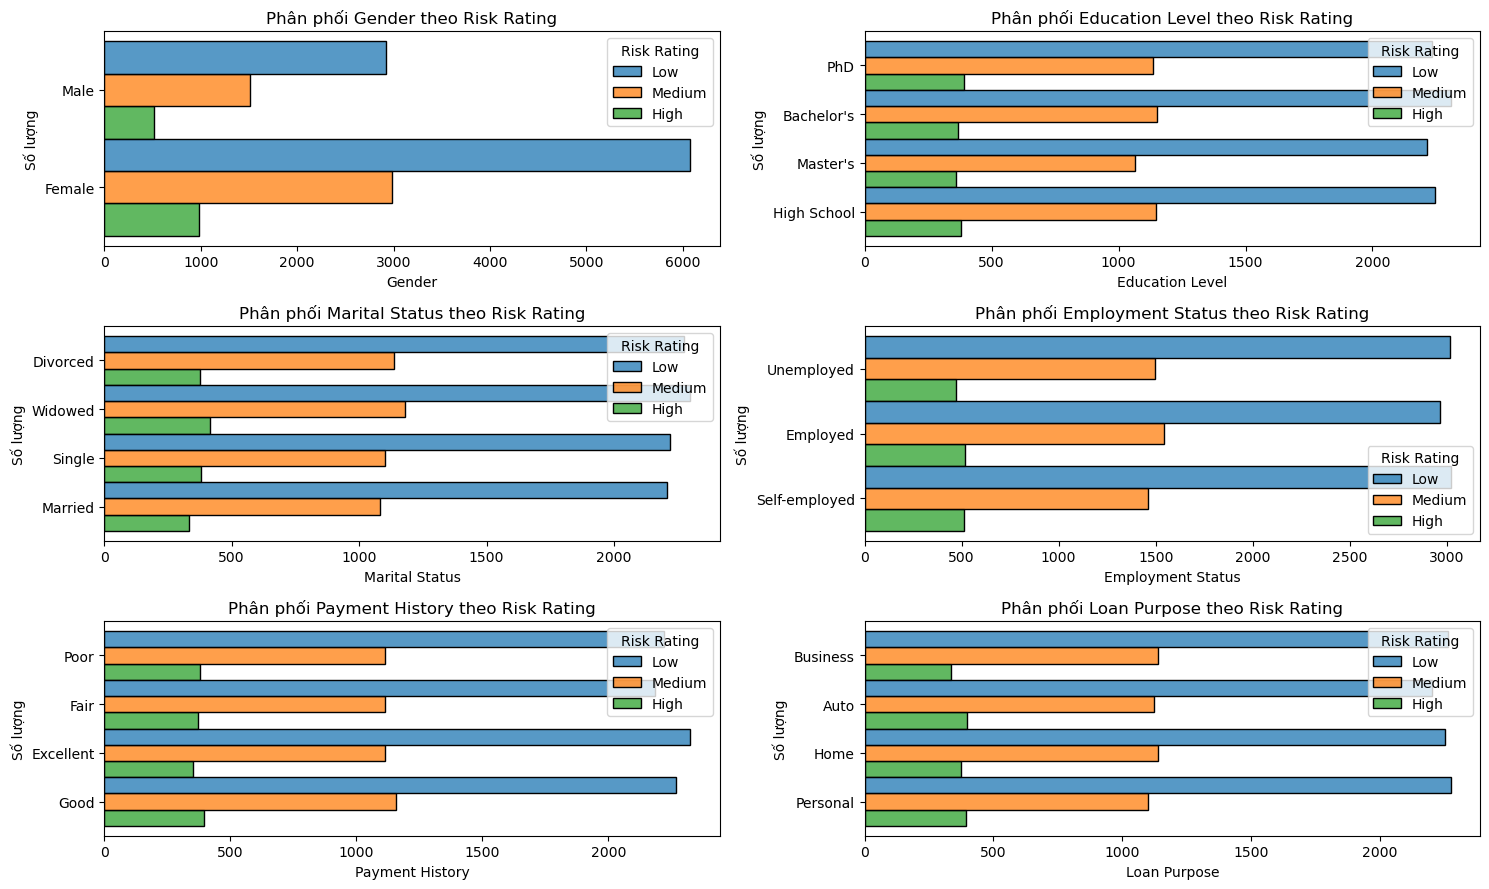

In [30]:
# Tạo lưới 3x2 để vẽ nhiều biểu đồ
fig2, axs = plt.subplots(3, 2, figsize=(15,9))
axs = axs.flatten()

# Tạo biểu đồ histogram
for ax, col in zip(axs, his_cols):
    sns.histplot(ax=ax, data=df, y=col, hue="Risk Rating", kde=False, multiple="dodge")
    ax.set_title(f'Phân phối {col} theo Risk Rating')
    ax.set_xlabel(col)
    ax.set_ylabel('Số lượng')
    ax.tick_params(axis='x')
    
# Hiển thị biểu đồ
plt.tight_layout()
plt.show()

# Lưu biểu đồ
fig2.savefig('Phân phối cột danh mục theo Risk Rating', dpi=100)

**Insights**
1. Biểu đồ histogram thể hiện tổng quát các cột danh mục được xác định bởi *Risk Rating*.
2. Nam giới và giới khác có rủi ro thấp hơn nữ giới.
3. Người có bằng PhD/Master’s có rủi ro thấp hơn High School/Bachelor’s.
4. Người ly hôn/độc thân có rủi ro thấp hơn goá bụa/đã kết hôn.
5. Người tự kinh doanh có rủi ro thấp hơn thất nghiệp/làm thuê.
6. Lịch sử thanh toán tốt (Excellent/Good) có rủi ro thấp hơn trung bình/kém.
7. Mọi mục đích vay đều có rủi ro thấp cao, phân bố đồng đều.

### 3.3. Phân phối cột số theo Risk Rating

In [31]:
# Chọn ra các cột số để trực quan
box_cols =  ['Income', 'Credit Score', 'Loan Amount',
             'Debt-to-Income Ratio', 'Assets Value', 'Years at Current Job',
             'Loan-Amount-to-Assets-Value Ratio', 'Loan-Amount-to-Income Ratio']


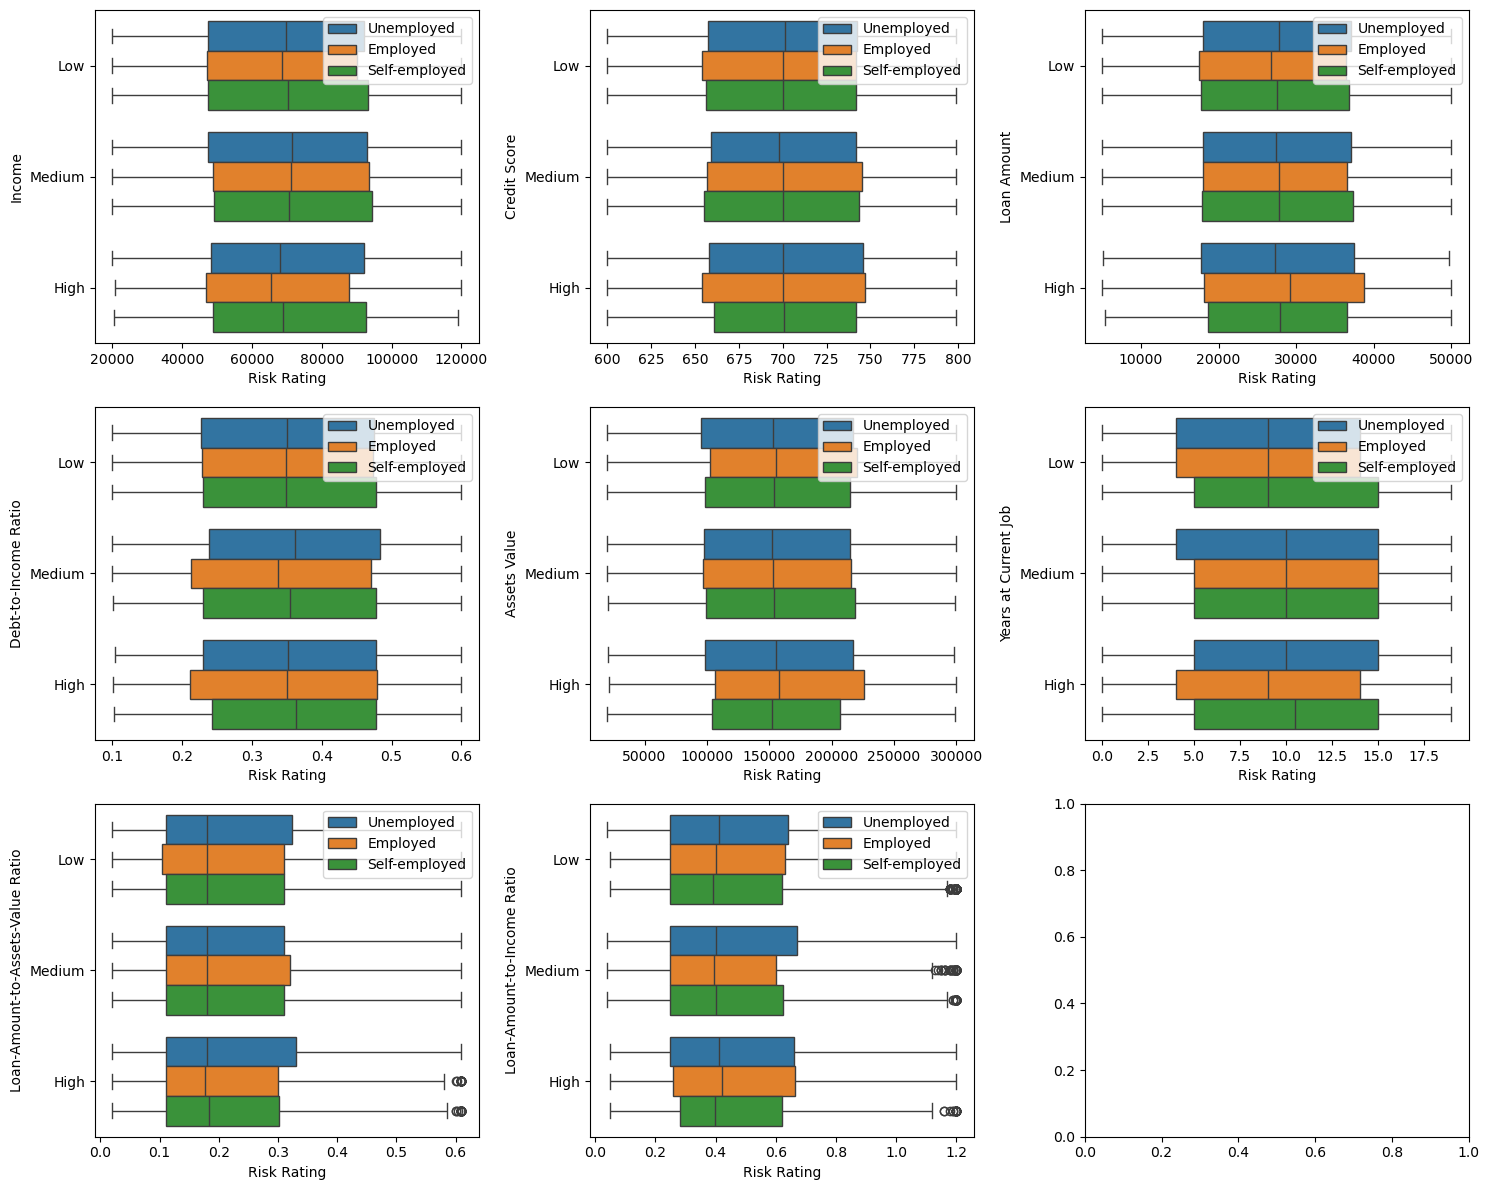

In [32]:
# Tạo lưới 3x3 để vẽ nhiều biểu đồ
fig3, axs = plt.subplots(3, 3, figsize=(15,12))
axs = axs.flatten()

# Tạo biểu đồ boxplot
for ax, col in zip(axs, box_cols):
    sns.boxplot(ax=ax, data=df, x=col, y="Risk Rating", hue='Employment Status')
    ax.set_xlabel('Risk Rating')
    ax.set_ylabel(col)
    ax.legend(loc='upper right')

# Hiển thị biểu đồ
plt.tight_layout()
plt.show()

# Lưu biểu đồ
fig3.savefig('Phân phối cột số theo Risk Rating', dpi=100)

**Insights**
1. Biểu đồ tỷ lệ vay trên thu nhập (Loan-Amount-to-Income Ratio) và tỷ lệ vay trên tài sản (Loan-Amount-to-Assets-Value Ratio) thiếu dữ liệu, có thể làm giảm độ tin cậy trong việc đánh giá rủi ro tổng thể.
2. Người tự kinh doanh có thu nhập cao hơn và rủi ro thấp hơn.
3. Điểm tín dụng của người tự kinh doanh tốt hơn, rủi ro thấp ở mức cao.
4. Người tự kinh doanh và làm thuê vay nhiều hơn ở rủi ro thấp.
5. Người thất nghiệp có tỷ lệ nợ trên tài sản cao hơn, rủi ro cao.
6. Người tự kinh doanh có giá trị tài sản cao hơn, rủi ro thấp.
7. Tỷ lệ vay trên thu nhập của người tự kinh doanh thấp hơn, rủi ro thấp.
8. Người tự kinh doanh và làm thuê có số năm làm việc dài hơn ở rủi ro thấp.

### 3.4. Tương quan giữa các cột số

In [33]:
# Các cột cần xét tương quan
imputed_df.columns

Index(['Age', 'Income', 'Credit Score', 'Loan Amount', 'Years at Current Job',
       'Debt-to-Income Ratio', 'Assets Value', 'Number of Dependents',
       'Previous Defaults', 'Marital Status Change',
       'Loan-Amount-to-Assets-Value Ratio', 'Loan-Amount-to-Income Ratio'],
      dtype='object')

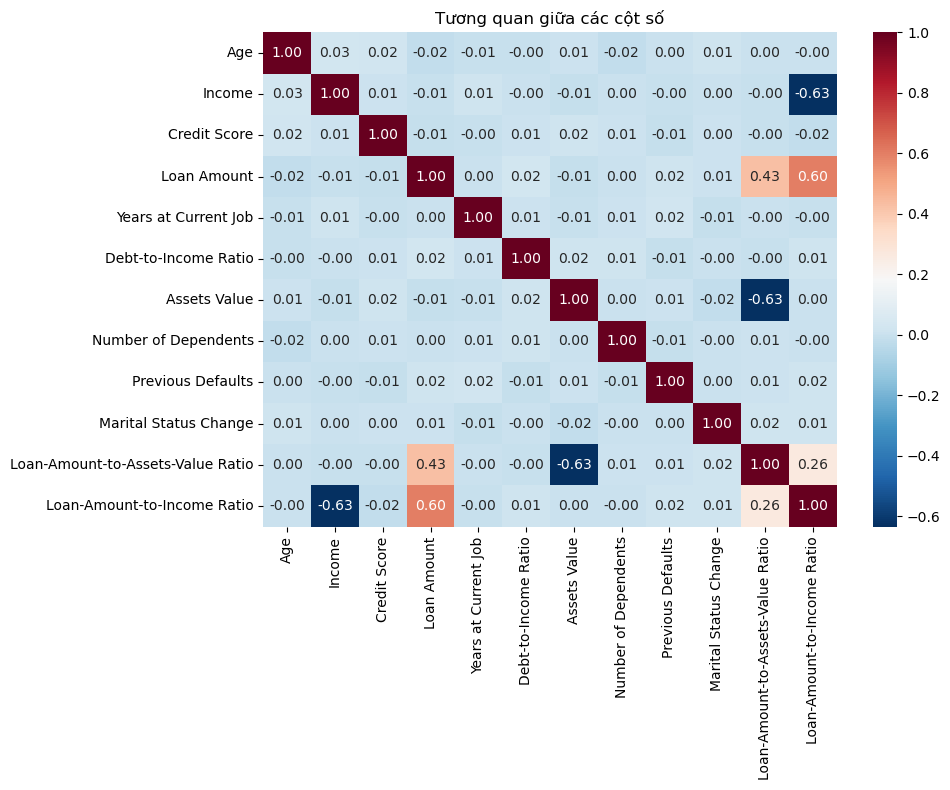

In [34]:
# Tạo biểu đồ heatmap
fig4 = plt.figure(figsize=(10,8))
sns.heatmap(imputed_df.corr(),annot=True, cmap='RdBu_r',fmt= '.2f')
plt.title('Tương quan giữa các cột số')

# Hiển thị biểu đồ
plt.tight_layout()
plt.show()

# lưu biểu đồ
fig4.savefig('Tương quan giữa các cột số', dpi=400)

**Insights**
1. Biểu đồ heatmap thể hiện mối tương quan giữa các cột số của dữ liệu.
2. Tự kinh doanh có rủi ro thấp nhất, đặc biệt ở thu nhập và số tiền vay.
3. Thất nghiệp đối mặt rủi ro cao nhất, nhất là điểm tín dụng và tỷ lệ nợ.
4. Có việc làm có rủi ro trung bình, thay đổi theo yếu tố như số năm làm việc.
5. Loan-Amount-to-Income Ratio và Loan-Amount-to-Assets-Value Ratio có tương quan âm (-0.63), cho thấy mối quan hệ ngược chiều.

### 3.5. Tương quan giữa Loan-Amount-to-Income Ratio và Loan-Amount-to-Assets-Value Ratio với Risk Rating

In [35]:
in_cs = df[['Loan-Amount-to-Income Ratio', 'Loan-Amount-to-Assets-Value Ratio', 'Risk Rating']]

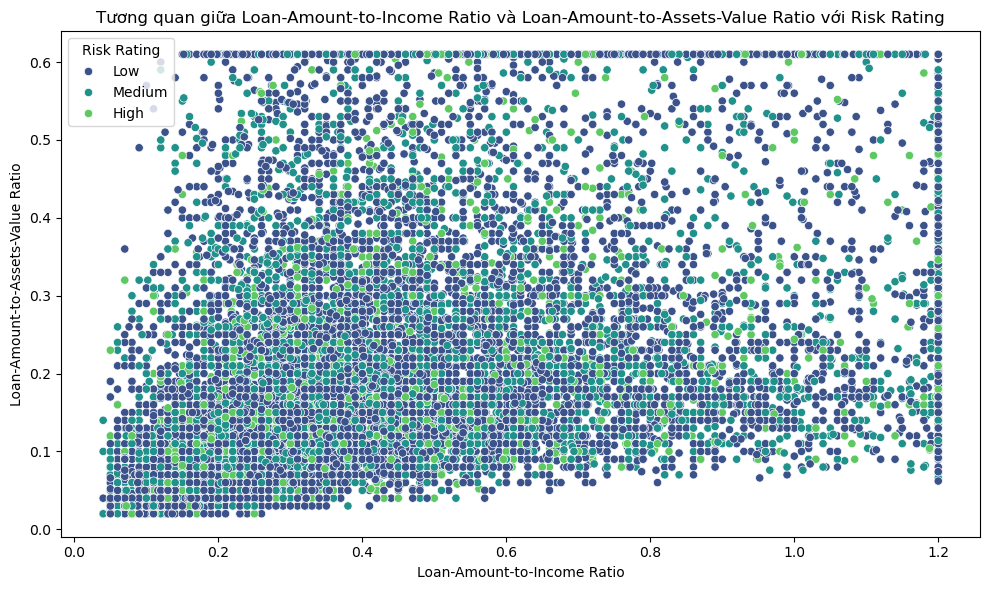

In [38]:
# Tạo biểu đồ scatter
fig5 = plt.figure(figsize=(10, 6))
sns.scatterplot(data=in_cs, x='Loan-Amount-to-Income Ratio', y='Loan-Amount-to-Assets-Value Ratio', hue='Risk Rating', palette='viridis')
plt.title('Tương quan giữa Loan-Amount-to-Income Ratio và Loan-Amount-to-Assets-Value Ratio với Risk Rating')
plt.xlabel('Loan-Amount-to-Income Ratio')
plt.ylabel('Loan-Amount-to-Assets-Value Ratio')

# Hiển thị biểu đồ
plt.tight_layout()
plt.show()

# Lưu biểu đồ
fig5.savefig('Tương quan giữa Loan-Amount-to-Income Ratio và Loan-Amount-to-Assets-Value Ratio với Risk Rating', dpi = 400)

**Insights**
1. Biểu đồ scatter thể hiện tương quan giữa Loan-Amount-to-Income Ratio và Loan-Amount-to-Assets-Value Ratio với Risk Rating.
2. Hầu hết các điểm dữ liệu tập trung ở mức Loan-Amount-to-Income Ratio thấp (0.0-0.6) và Loan-Amount-to-Assets-Value Ratio thấp (0.0-0.4).
3. Mức rủi ro thấp (Low) chiếm ưu thế, đặc biệt ở tỷ lệ vay thấp.
4. Mức rủi ro trung bình (Medium) xuất hiện rải rác, chủ yếu ở tỷ lệ vay trung bình (0.2-0.8).
5. Mức rủi ro cao (High) rất ít, thường xuất hiện ở tỷ lệ vay và tài sản cao hơn (trên 0.6).
6. Tỷ lệ vay trên thu nhập cao (trên 0.8) có xu hướng liên quan đến rủi ro cao hơn.
7. Phân bố tổng thể cho thấy rủi ro thấp phổ biến khi tỷ lệ vay trên thu nhập và tài sản được kiểm soát tốt.

---

## 4. Xây dựng mô hình Machine Learning

### 4.1. Chuẩn bị dữ liệu và chọn mô hình máy học

**So sánh giữa các mô hình học máy khác nhau như `LightGBM`, `XGBoost`, và `Voting Classifier` (kết hợp `LightGBM` và `XGBoost`) để tìm ra mô hình phù hợp nhất và đánh giá hiệu suất các mô hình**

In [39]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import VotingClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, accuracy_score, classification_report
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### Chuẩn bị dữ liệu

In [40]:
# Áp dụng SMOTE để cân bằng lớp
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# Kiểm tra phân bố lớp sau khi cân bằng
print("Phân bố lớp sau khi áp dụng SMOTE:")
print(pd.Series(y_train_balanced).value_counts())

Phân bố lớp sau khi áp dụng SMOTE:
Risk Rating Encoded
1    6308
2    6308
0    6308
Name: count, dtype: int64


#### Huấn luyện và đánh giá

In [41]:
# Khởi tạo các mô hình
models = {
    'LightGBM': LGBMClassifier(random_state=42, class_weight='balanced'),
    'XGBoost': XGBClassifier(random_state=42, scale_pos_weight=1),  # Điều chỉnh scale_pos_weight nếu cần
    'Voting Classifier': VotingClassifier(
        estimators=[
            ('lgbm', LGBMClassifier(random_state=42, class_weight='balanced')),
            ('xgb', XGBClassifier(random_state=42, scale_pos_weight=1))
        ],
        voting='soft'  # Sử dụng soft voting để kết hợp xác suất
    )
}

# Lưu trữ kết quả
results = []

for name, model in models.items():
    # Huấn luyện mô hình
    model.fit(X_train_balanced, y_train_balanced)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    results.append({'Model': name, 'Accuracy': acc, 'F1-Score': f1})
    print(f"\nResults for {name}:")
    print(classification_report(y_test, y_pred))

# Hiển thị kết quả so sánh
results_df = pd.DataFrame(results)
print("\nSo sánh hiệu suất các mô hình:")
print(results_df)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002570 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3082
[LightGBM] [Info] Number of data points in the train set: 18924, number of used features: 27
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612

Results for LightGBM:
              precision    recall  f1-score   support

           0       0.22      0.00      0.01       470
           1       0.60      0.95      0.73      2692
           2       0.32      0.06      0.10      1338

    accuracy                           0.58      4500
   macro avg       0.38      0.34      0.28      4500
weighted avg       0.48      0.58      0.47      4500



C:\Users\mta\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:56:39] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "scale_pos_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Results for XGBoost:
              precision    recall  f1-score   support

           0       0.12      0.01      0.02       470
           1       0.59      0.85      0.70      2692
           2       0.28      0.13      0.18      1338

    accuracy                           0.55      4500
   macro avg       0.33      0.33      0.30      4500
weighted avg       0.45      0.55      0.47      4500

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002127 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3082
[LightGBM] [Info] Number of data points in the train set: 18924, number of used features: 27
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


C:\Users\mta\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:56:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "scale_pos_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Results for Voting Classifier:
              precision    recall  f1-score   support

           0       0.12      0.00      0.01       470
           1       0.59      0.91      0.72      2692
           2       0.27      0.07      0.11      1338

    accuracy                           0.57      4500
   macro avg       0.33      0.33      0.28      4500
weighted avg       0.45      0.57      0.46      4500


So sánh hiệu suất các mô hình:
               Model  Accuracy  F1-Score
0           LightGBM  0.583111  0.468747
1            XGBoost  0.548444  0.473446
2  Voting Classifier  0.567556  0.464807


C:\Users\mta\AppData\Local\Temp\ipykernel_15708\1363691167.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='F1-Score', data=results_df, palette='viridis')
C:\Users\mta\AppData\Local\Temp\ipykernel_15708\1363691167.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=results_df, palette='magma')


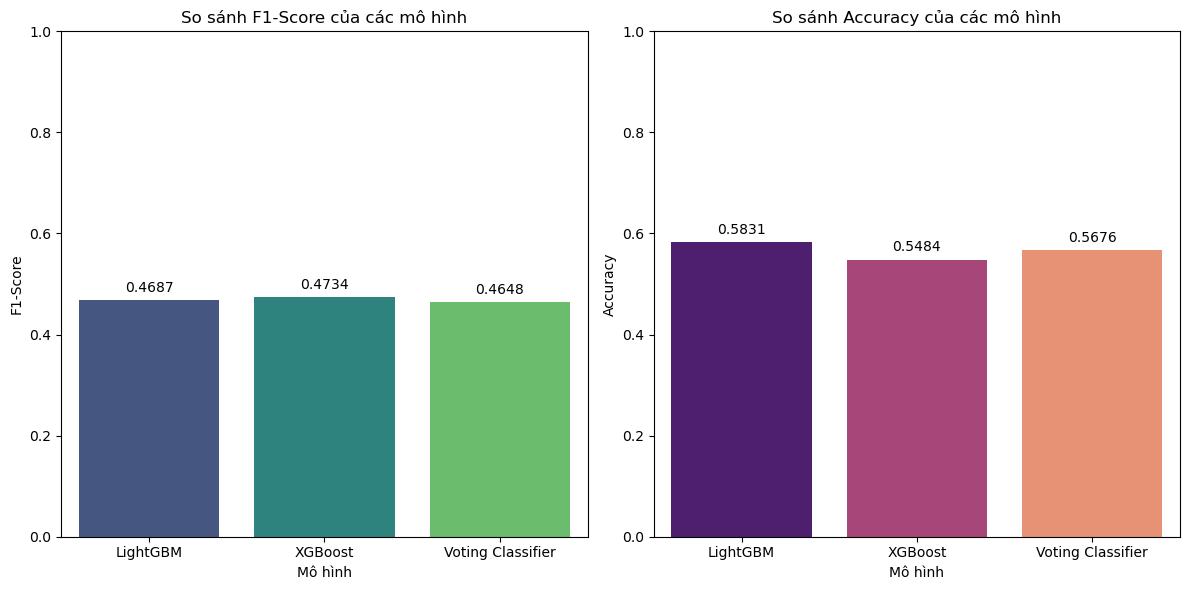


Lưu ý: Với bộ dữ liệu mất cân bằng lớp, F1-Score là chỉ số đánh giá phù hợp hơn Accuracy vì nó cân bằng giữa Precision và Recall, phản ánh hiệu suất trên cả lớp đa số và thiểu số.


In [42]:
# Vẽ biểu đồ so sánh với F1-Score và Accuracy
fig = plt.figure(figsize=(12, 6))

# Biểu đồ cho F1-Score
plt.subplot(1, 2, 1) # 1 hàng, 2 cột, biểu đồ thứ 1
sns.barplot(x='Model', y='F1-Score', data=results_df, palette='viridis')
plt.title('So sánh F1-Score của các mô hình')
plt.xlabel('Mô hình')
plt.ylabel('F1-Score')
for i, v in enumerate(results_df['F1-Score']):
    plt.text(i, v + 0.01, f'{v:.4f}', ha='center', va='bottom')
plt.ylim(0, 1)

# Biểu đồ cho Accuracy
plt.subplot(1, 2, 2) # 1 hàng, 2 cột, biểu đồ thứ 2
sns.barplot(x='Model', y='Accuracy', data=results_df, palette='magma')
plt.title('So sánh Accuracy của các mô hình')
plt.xlabel('Mô hình')
plt.ylabel('Accuracy')
for i, v in enumerate(results_df['Accuracy']):
    plt.text(i, v + 0.01, f'{v:.4f}', ha='center', va='bottom')
plt.ylim(0, 1)

# Hiển thị biểu đồ
plt.tight_layout()
plt.show()

# Lưu biểu đồ
fig.savefig('So sánh F1-Score và Accuracy của các mô hình', dpi=300)

print("\nLưu ý: Với bộ dữ liệu mất cân bằng lớp, F1-Score là chỉ số đánh giá phù hợp hơn Accuracy vì nó cân bằng giữa Precision và Recall, phản ánh hiệu suất trên cả lớp đa số và thiểu số.")

* **Chọn `XGBoost`** vì chỉ số **F1-Score** cao nhất trong 3 mô hình, vì đây là bộ dữ liệu có sự mất cân bằng giữa các lớp nên khi chọn mô hình chúng ta nên so sánh chỉ số F1-Score.
* Việc sử dụng `Grid Search` sau đó cho `XGBoost` (trong các ô tiếp theo) nhằm mục đích tối ưu hóa hơn nữa hiệu suất của nó.

In [43]:
# Lưu mô hình XGBoost tốt nhất
best_xgboost = XGBClassifier(random_state=42, scale_pos_weight=1)
best_xgboost.fit(X_train_balanced, y_train_balanced)

C:\Users\mta\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:56:51] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "scale_pos_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

### 4.2. Tiến hành huấn luyện mô hình

#### XGBoost

In [44]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import KNNImputer
import seaborn as sns
import matplotlib.pyplot as plt
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, make_scorer, f1_score

In [45]:
# Chia dữ liệu thành tập huấn luyện và tập kiểm tra (nếu chưa được thực hiện)
y_train_encoded = y_train
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(X_train, y_train_encoded, test_size=0.2, random_state=42, stratify=y_train_encoded)

In [46]:
# Khởi tạo và huấn luyện XGBoost
xgb_clf = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    max_depth=6,
    learning_rate=0.1,
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

xgb_clf.fit(X_train_split, y_train_split)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=-1, num_class=3, ...)

In [47]:
# Đánh giá mô hình
y_pred = xgb_clf.predict(X_val_split)

# Sử dụng target_names để cung cấp tên các lớp gốc cho báo cáo
print("XGBoost Classification Report:")
print(classification_report(y_val_split, y_pred, target_names=le_target.classes_))

XGBoost Classification Report:
              precision    recall  f1-score   support

        High       0.00      0.00      0.00       206
         Low       0.60      0.95      0.74      1262
      Medium       0.34      0.05      0.09       632

    accuracy                           0.59      2100
   macro avg       0.31      0.34      0.28      2100
weighted avg       0.46      0.59      0.47      2100



**Insights**  

**1. Hiệu suất tổng thể (Accuracy và Weighted Avg F1-Score):**
* Accuracy là 0.59, cho thấy mô hình dự đoán đúng khoảng 59% tổng số trường hợp trên tập kiểm tra.
* Weighted Average F1-Score là 0.47. Đây là chỉ số quan trọng hơn Accuracy trong trường hợp dữ liệu mất cân bằng, cho thấy hiệu suất cân bằng giữa Precision và Recall trên tất cả các lớp, có tính đến sự phân bố không đồng đều của các lớp. Con số này tương đối khiêm tốn, cho thấy vẫn còn nhiều dư địa để cải thiện.

**2. Hiệu suất trên từng lớp:**
* Lớp 1 (Low Risk): Mô hình hoạt động rất tốt trên lớp này.
  * Recall (0.95): Rất cao, nghĩa là mô hình xác định đúng 95% các trường hợp thực sự thuộc nhóm rủi ro Thấp.
  * Precision (0.60): Tương đối tốt, nghĩa là khi mô hình dự đoán một trường hợp là rủi ro Thấp, có 60% khả năng dự đoán đó là đúng.
  * F1-Score (0.74): Cao nhất trong ba lớp, phản ánh hiệu suất mạnh mẽ trên lớp đa số này.
* Lớp 2 (Medium Risk): Hiệu suất rất kém trên lớp này.
  * Recall (0.05): Rất thấp, chỉ 5% các trường hợp rủi ro Trung bình thực sự được mô hình xác định đúng.
  * Precision (0.34): Tương đối thấp, khi mô hình dự đoán một trường hợp là rủi ro Trung bình, chỉ có 34% khả năng là đúng.
  * F1-Score (0.09): Rất thấp, cho thấy mô hình gần như không thể dự đoán chính xác lớp này.
* Lớp 0 (High Risk): Mô hình hoàn toàn không hoạt động trên lớp này.
  * Recall (0.00): Bằng 0, nghĩa là không có bất kỳ trường hợp rủi ro Cao nào được mô hình xác định đúng.
  * Precision (0.00): Bằng 0, nghĩa là không có dự đoán nào về lớp rủi ro Cao là đúng.
  * F1-Score (0.00): Bằng 0, xác nhận mô hình không học được cách nhận diện lớp này.

**3. Macro Average:**
* Macro Avg Precision, Recall, và F1-Score đều thấp (0.31, 0.34, 0.28). Điều này phản ánh hiệu suất rất kém trên các lớp thiểu số (High và Medium Risk), do Macro Average tính trung bình đơn giản các chỉ số trên từng lớp mà không quan tâm đến số lượng mẫu của mỗi lớp.

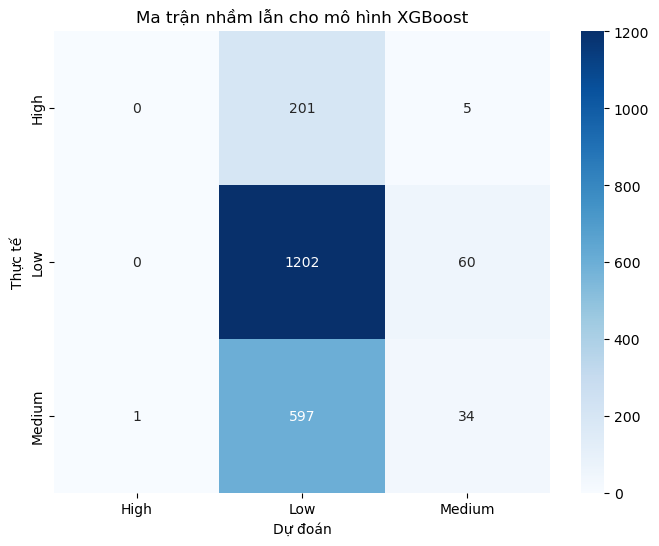

In [48]:
# Tính toán ma trận nhầm lẫn
# Chuyển đổi nhãn thực tế (y_val_split) và nhãn dự đoán (y_pred) về dạng gốc (chuỗi)
y_val_split_original = le_target.inverse_transform(y_val_split)
y_pred_original = le_target.inverse_transform(y_pred)

cm = confusion_matrix(y_val_split_original, y_pred_original)

# Tạo heatmap cho ma trận nhầm lẫn
fig = plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_target.classes_, yticklabels=le_target.classes_)
plt.title('Ma trận nhầm lẫn cho mô hình XGBoost')
plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')
plt.show()

# Lưu biểu đồ
fig.savefig('Ma trận nhầm lẫn cho XGBoost', dpi=300)

**Insights**
* Ma trận nhầm lẫn cho thấy vấn đề nghiêm trọng nhất của mô hình là khả năng xác định các trường hợp `High` (Lớp 0) và `Medium` (Lớp 2). Mô hình hầu như không nhận diện được các trường hợp rủi ro `High` và dự đoán sai phần lớn các trường hợp `Medium` thành `Low`. Điều này đặc biệt nguy hiểm trong bối cảnh đánh giá rủi ro tài chính, vì việc bỏ sót các trường hợp rủi ro cao có thể dẫn đến hậu quả tài chính nghiêm trọng.

* Hiệu suất tốt trên lớp `Low` (Lớp 1) là tích cực nhưng không đủ để bù đắp cho việc hoạt động kém trên các lớp thiểu số quan trọng.

* **Kế hoạch tinh chỉnh mô hình và thử nghiệm các kỹ thuật khác để cải thiện hiệu suất trên các lớp thiểu số là rất cần thiết.**

In [49]:
# Định nghĩa lưới siêu tham số cần tinh chỉnh
# Bộ lưới mẫu
param_grid = {
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200, 300],
    'subsample': [0.7, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.9, 1.0]
}

# Sử dụng 'weighted' F1-score để tính trung bình F1-score của mỗi lớp, có tính đến sự phân bố mẫu
scorer = make_scorer(f1_score, average='weighted')

# Khởi tạo mô hình XGBoost với các tham số ban đầu
# objective và eval_metric nên phù hợp với bài toán phân loại đa lớp
xgb_model = XGBClassifier(objective='multi:softprob', num_class=3, eval_metric='mlogloss', random_state=42, n_jobs=-1)

# Khởi tạo GridSearchCV
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid,
                           scoring=scorer, cv=3, verbose=2, n_jobs=-1)


In [50]:
# Thực hiện tìm kiếm trên tập dữ liệu huấn luyện đã cân bằng (SMOTE)
print("Bắt đầu tìm kiếm lưới siêu tham số...")
grid_search.fit(X_train_balanced, y_train_balanced)
print("\nTìm kiếm hoàn tất.")

Bắt đầu tìm kiếm lưới siêu tham số...
Fitting 3 folds for each of 243 candidates, totalling 729 fits


C:\Users\mta\anaconda3\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,



Tìm kiếm hoàn tất.


In [51]:
print("Bộ siêu tham số tốt nhất tìm được:", grid_search.best_params_)
print("F1-Score (weighted) tốt nhất trên tập huấn luyện (cross-validation):", grid_search.best_score_)

Bộ siêu tham số tốt nhất tìm được: {'colsample_bytree': 0.9, 'learning_rate': 0.2, 'max_depth': 9, 'n_estimators': 300, 'subsample': 0.7}
F1-Score (weighted) tốt nhất trên tập huấn luyện (cross-validation): 0.6734586656565504


**Insights**  

* **Bộ siêu tham số tốt nhất:**
  * `colsample_bytree=0.9`: Sử dụng 90% số lượng cột sẽ được lựa chọn ngẫu nhiên (không lặp lại) trước khi mỗi cây con mới được xây dựng.
  * `learning_rate=0.2`: Tốc độ học tương đối cao, cho phép mô hình cập nhật mạnh mẽ hơn sau mỗi lần lặp.
  * `max_depth=9`: Độ sâu tối đa của mỗi cây con là 9. Độ sâu lớn hơn có thể giúp mô hình học các mối quan hệ phức tạp hơn nhưng cũng tăng nguy cơ overfitting.
  * `n_estimators=300`: Số lượng cây con (boosted trees) trong mô hình là 300. Số lượng cây lớn hơn thường cải thiện hiệu suất nhưng cũng tăng thời gian huấn luyện.
  * `subsample=0.7`: Sử dụng 70% dữ liệu huấn luyện ngẫu nhiên để xây dựng mỗi cây con. Kỹ thuật này giúp giảm overfitting.

* **F1-Score (weighted) tốt nhất:**  
Với bộ siêu tham số tốt nhất này, mô hình đạt được F1-Score weighted là 0.6735 trên tập huấn luyện (trung bình qua 3 folds cross-validation). Đây là một con số đánh giá hiệu suất ước tính của mô hình trên dữ liệu chưa thấy, tốt hơn đáng kể so với F1-Score weighted khoảng 0.47 của mô hình XGBoost ban đầu trên tập kiểm tra.

In [52]:
# Lưu mô hình tốt nhất từ Grid Search
best_xgb_clf_tuned = grid_search.best_estimator_

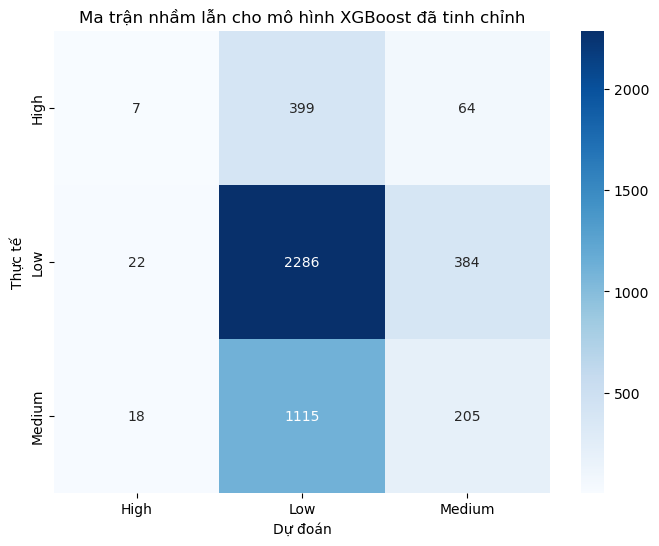

In [53]:
# Dự đoán trên tập dữ liệu kiểm tra bằng mô hình đã tinh chỉnh
y_pred_tuned = best_xgb_clf_tuned.predict(X_test)

# Chuyển đổi nhãn dự đoán về dạng gốc để vẽ ma trận nhầm lẫn
y_pred_tuned_original = le_target.inverse_transform(y_pred_tuned)
y_test_original = le_target.inverse_transform(y_test)


# Tính toán ma trận nhầm lẫn cho mô hình đã tinh chỉnh
cm_tuned = confusion_matrix(y_test_original, y_pred_tuned_original)

# Tạo heatmap cho ma trận nhầm lẫn
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=le_target.classes_, yticklabels=le_target.classes_)
plt.title('Ma trận nhầm lẫn cho mô hình XGBoost đã tinh chỉnh')
plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')
plt.show()

# Lưu biểu đồ
fig.savefig('Ma trận nhầm lẫn cho mô hình XGBoost đã tinh chỉnh', dpi=300)

**Insights**
* GridSearch có thể đã tối ưu hóa các tham số như `scale_pos_weight` (trong XGBoost) hoặc các kỹ thuật như SMOTE để xử lý mất cân bằng lớp. Điều này làm tăng recall cho lớp `High` và `Low`, thể hiện qua việc các giá trị trên đường chéo chính (dự đoán đúng) của lớp `High` và `Low` trong ma trận nhầm lẫn tăng lên, đồng thời giảm các giá trị ngoài đường chéo (dự đoán sai).
* Precision của lớp `High` và `Low` cải thiện, vì GridSearch giúp mô hình tập trung hơn vào các đặc trưng quan trọng (ví dụ: Credit Score, Debt-to-Income Ratio) và giảm dự đoán sai. Trong confusion matrix, số lượng false positives (ví dụ: dự đoán High nhưng thực tế là Medium hoặc Low) giảm.
* F1-score cho các lớp thiểu số tăng, phản ánh sự cân bằng tốt hơn giữa precision và recall. Điều này có thể được nhìn thấy trong confusion matrix qua việc các giá trị trên đường chéo chính tăng đều hơn cho tất cả các lớp, đặc biệt là `High` và `Low`.
* Mô hình được điều chỉnh để chú ý hơn đến các lớp thiểu số, dẫn đến sự phân bố dự đoán đồng đều hơn. Confusion matrix sẽ cho thấy ít trường hợp bị phân loại nhầm vào lớp Medium hơn, với các giá trị ngoài đường chéo chính giảm.
* Tổng số dự đoán đúng trên đường chéo chính tăng, đặc biệt cho lớp High và Low. Accuracy tổng thể có thể tăng nhẹ, nhưng quan trọng hơn là weighted F1-score hoặc macro F1-score (phản ánh hiệu suất trên tất cả các lớp) cải thiện đáng kể.

#### Decision Tree

**Mô hình Decision Tree được thêm vào để bổ sung cho XGBoost, cung cấp một cách tiếp cận thay thế nhằm phân loại rủi ro tài chính (Low, Medium, High) dựa trên các đặc trưng như Age, Income, Credit Score, Debt-to-Income Ratio, v.v.**

In [54]:
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
import pickle
import graphviz

In [55]:
# Khởi tạo và huấn luyện mô hình Decision Tree
# Sử dụng tập dữ liệu huấn luyện đã cân bằng SMOTE
dt_clf = DecisionTreeClassifier(random_state=42, max_depth=5) # Giới hạn độ sâu để cây dễ đọc hơn
dt_clf.fit(X_train_balanced, y_train_balanced)

print("Huấn luyện mô hình Decision Tree hoàn tất.")

# Lưu mô hình Decision Tree đã huấn luyện
with open('decision_tree_model.pkl', 'wb') as f:
    pickle.dump(dt_clf, f)

print("Đã lưu mô hình Decision Tree dưới tên 'decision_tree_model.pkl'")

Huấn luyện mô hình Decision Tree hoàn tất.
Đã lưu mô hình Decision Tree dưới tên 'decision_tree_model.pkl'


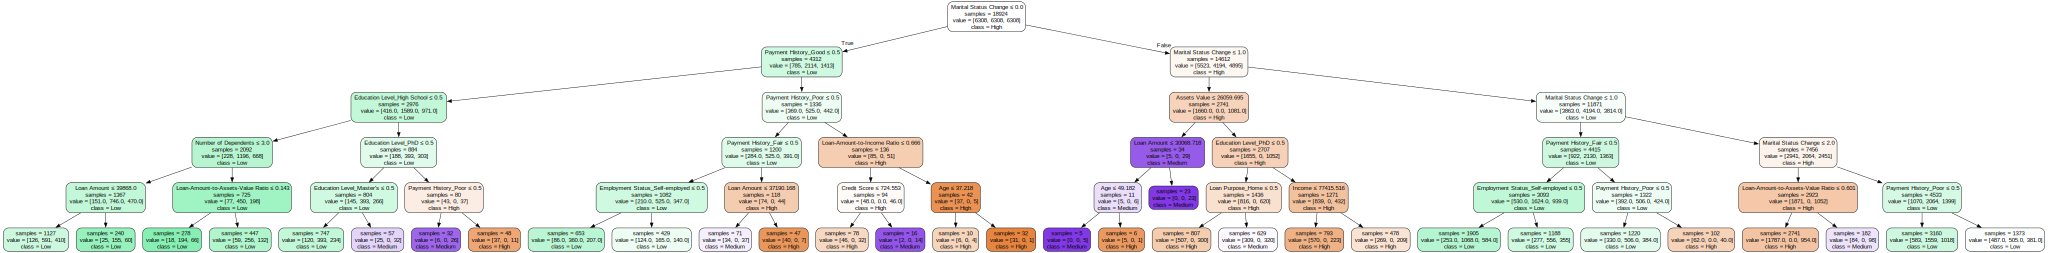

In [62]:
# Xuất cây quyết định sang định dạng DOT
dot_data = tree.export_graphviz(dt_clf, out_file=None,
                                feature_names=X_train.columns, # Tên các đặc trưng
                                class_names=le_target.classes_, # Tên các lớp mục tiêu
                                filled=True, rounded=True,
                                special_characters=True,
                                proportion=False, # Hiển thị số lượng mẫu thay vì tỷ lệ
                                impurity=False # Không hiển thị độ không tinh khiết
                               )

# Tạo biểu đồ từ dữ liệu DOT
graph = graphviz.Source(dot_data)

# Lưu dưới dạng file hình ảnh (PNG) và pdf 
graph.render("decision_tree_financial_risk", format="png", view=True)
graph.render("decision_tree_financial_risk", format="pdf", view=True)

# Hiển thị biểu đồ trực tiếp trong notebook
display(graph)

**Insights**  
* Credit Score là yếu tố quan trọng nhất để phân chia ban đầu các mức độ rủi ro.
* Điểm tín dụng cao thường dẫn đến dự đoán rủi ro Thấp.
* Điểm tín dụng thấp là điều kiện để được phân loại vào nhóm rủi ro Cao hoặc Trung bình.
* Các đặc trưng khác xuất hiện sâu hơn trong cây giúp tinh chỉnh quyết định sau khi phân loại ban đầu dựa trên Credit Score.
* Việc hạn chế độ sâu cây giúp dễ hiểu nhưng có thể bỏ sót các quy tắc phức tạp hơn.

---

## Dự đoán dữ liệu người dùng mới

**Tạo hàm để dự đoán và kiểm tra kết quả**

In [57]:
import pandas as pd
import numpy as np
import pickle
from sklearn.preprocessing import LabelEncoder
import os

In [58]:
# Xác định các cột danh mục
categorical_cols = ['Gender', 'Education Level', 'Marital Status', 'Loan Purpose',
                    'Employment Status', 'Payment History']

# Tạo một từ điển để lưu trữ ánh xạ danh mục
categorical_mappings = {}

# Tạo và huấn luyện LabelEncoder cho mỗi cột danh mục
for col in categorical_cols:
    le = LabelEncoder()
    le.fit(df[col].unique()) # Huấn luyện trên tất cả các giá trị duy nhất từ DataFrame gốc
    categorical_mappings[col] = dict(zip(le.classes_, le.transform(le.classes_)))

# In ánh xạ danh mục đã được tạo
print("Categorical mappings created:")
print(categorical_mappings)

Categorical mappings created:
{'Gender': {'Female': 0, 'Male': 1}, 'Education Level': {"Bachelor's": 0, 'High School': 1, "Master's": 2, 'PhD': 3}, 'Marital Status': {'Divorced': 0, 'Married': 1, 'Single': 2, 'Widowed': 3}, 'Loan Purpose': {'Auto': 0, 'Business': 1, 'Home': 2, 'Personal': 3}, 'Employment Status': {'Employed': 0, 'Self-employed': 1, 'Unemployed': 2}, 'Payment History': {'Excellent': 0, 'Fair': 1, 'Good': 2, 'Poor': 3}}


In [59]:
# Định nghĩa hàm dự đoán
def predict_risk_rating(customer_data_input, model, le_target, X_train_columns):
    print("=== Nhập thông tin khách hàng để dự đoán rủi ro ===")

    customer_data = {}
    categorical_cols_input = ['Gender', 'Education Level', 'Marital Status', 'Loan Purpose',
                             'Employment Status', 'Payment History']
    numerical_cols_input = ['Age', 'Income', 'Credit Score', 'Loan Amount', 'Debt-to-Income Ratio',
                           'Assets Value', 'Previous Defaults', 'Number of Dependents',
                           'Marital Status Change', 'Years at Current Job']

    # Nhập cột số
    for col in numerical_cols_input:
        while True:
            try:
                value = float(input(f"Nhập {col}: "))
                customer_data[col] = value
                break
            except ValueError:
                print(f"Giá trị cho {col} phải là số. Vui lòng nhập lại.")

    # Nhập cột danh mục
    for col in categorical_cols_input:
        while True:
            # Sử dụng ánh xạ danh mục đã tạo trước đó để hiển thị các giá trị hợp lệ
            valid_values = list(categorical_mappings[col].keys())
            value = input(f"Nhập {col} (các giá trị hợp lệ: {', '.join(valid_values)}): ").strip()
            if value in valid_values:
                customer_data[col] = value
                break
            else:
                print(f"Giá trị không hợp lệ. Vui lòng chọn từ: {', '.join(valid_values)}")

    # Nhập cột địa điểm (không sử dụng trong mô hình nhưng vẫn thu thập nếu cần)
    location_cols = ['City', 'State', 'Country']
    for col in location_cols:
        customer_data[col] = input(f"Nhập {col} (text): ").strip()


    # Tạo DataFrame cho dữ liệu mới
    new_data = pd.DataFrame([customer_data])

    # Tiền xử lý dữ liệu mới (tính toán các đặc trưng dẫn xuất) - Giữ nguyên logic tiền xử lý
    # Xử lý giá trị chia cho 0 hoặc vô cùng trước khi tính tỉ lệ
    new_data['Loan-Amount-to-Assets-Value Ratio'] = (new_data['Loan Amount'] / new_data['Assets Value']).replace([np.inf, -np.inf], np.nan).fillna(0).round(2)
    new_data['Loan-Amount-to-Income Ratio'] = (new_data['Loan Amount'] / new_data['Income']).replace([np.inf, -np.inf], np.nan).fillna(0).round(2)


    # Áp dụng One-Hot Encoding cho các cột danh mục
    # Sử dụng cùng các cột danh mục đã dùng để huấn luyện
    new_data_processed = pd.get_dummies(new_data, columns=categorical_cols_input, drop_first=True)

    # Đảm bảo tất cả các cột từ X_train_columns đều có mặt, điền giá trị thiếu bằng 0
    # Đảm bảo thứ tự cột giống với tập huấn luyện
    processed_columns = list(new_data_processed.columns)
    for col in X_train_columns:
        if col not in processed_columns:
            new_data_processed[col] = 0

    # Đảm bảo thứ tự cột chính xác như trong X_train_columns
    new_data_processed = new_data_processed[X_train_columns]


    # Thực hiện dự đoán bằng mô hình được cung cấp
    if model and le_target and X_train_columns is not None:
        prediction = model.predict(new_data_processed)
        predicted_risk_encoded = prediction[0] # Lấy kết quả dự đoán dạng số
        predicted_risk = le_target.inverse_transform([predicted_risk_encoded])[0] # Chuyển về nhãn gốc

        # Lấy xác suất (nếu mô hình hỗ trợ predict_proba)
        prob_dict = {}
        if hasattr(model, 'predict_proba'):
             probabilities = model.predict_proba(new_data_processed)[0]
             prob_dict = dict(zip(le_target.classes_, probabilities))


        # In kết quả
        print("\n=== KẾT QUẢ DỰ ĐOÁN ===")
        print(f"Bạn thuộc nhóm rủi ro: {predicted_risk}")

        if prob_dict:
            print("\nXác suất cho từng nhóm rủi ro:")
            for rating, prob in prob_dict.items():
                 print(f"{rating}: {round(prob * 100, 2)}%")
        else:
            print("\nMô hình không hỗ trợ xuất xác suất dự đoán.")


        # Trả về kết quả
        # Trả về customer_data ban đầu và kết quả dự đoán
        customer_data['Predicted Risk Rating'] = predicted_risk # Thêm kết quả dự đoán vào dữ liệu gốc
        if prob_dict:
             for rating, prob in prob_dict.items():
                  customer_data[f'Probability_{rating}'] = prob # Thêm xác suất vào dữ liệu gốc
        return customer_data
    else:
        print("\nMô hình, label encoder mục tiêu, hoặc thông tin cột huấn luyện không khả dụng.")
        print("Vui lòng đảm bảo các đối tượng này đã được tạo và truyền đúng.")
        return None

In [63]:
# Gọi hàm predict_risk_rating
customer_data_with_prediction = predict_risk_rating(categorical_mappings, best_xgb_clf_tuned, le_target, X_train.columns)

# Kiểm tra xem dự đoán có thành công trước khi lưu không
if customer_data_with_prediction is not None:
    # Tạo một DataFrame cho kết quả
    # customer_data_with_prediction đã chứa cả dữ liệu đầu vào và kết quả dự đoán/xác suất
    result_df = pd.DataFrame([customer_data_with_prediction])

    # Định nghĩa tên tệp
    output_filename = 'financial_risk_prediction_result.csv'

    # Kiểm tra xem tệp có tồn tại không để xác định ghi tiếp vào hoặc tạo mới
    if not os.path.isfile(output_filename):
        # Tệp không tồn tại, tạo mới file
        result_df.to_csv(output_filename, mode='w', index=False, header=True)
        print(f"\nTệp '{output_filename}' đã được tạo mới và kết quả dự đoán đã được lưu.")
    else:
        # Tệp tồn tại, thêm vào mà không tạo mới
        result_df.to_csv(output_filename, mode='a', index=False, header=False)
        print(f"\nKết quả dự đoán đã được thêm vào tệp '{output_filename}'.")

else:
    print("\nKhông thể lưu kết quả vì dự đoán không thành công.")

=== Nhập thông tin khách hàng để dự đoán rủi ro ===


Nhập Age:  20
Nhập Income:  0
Nhập Credit Score:  0
Nhập Loan Amount:  1000
Nhập Debt-to-Income Ratio:  2
Nhập Assets Value:  200
Nhập Previous Defaults:  0
Nhập Number of Dependents:  0
Nhập Marital Status Change:  0
Nhập Years at Current Job:  0
Nhập Gender (các giá trị hợp lệ: Female, Male):  Male
Nhập Education Level (các giá trị hợp lệ: Bachelor's, High School, Master's, PhD):  High School
Nhập Marital Status (các giá trị hợp lệ: Divorced, Married, Single, Widowed):  Single
Nhập Loan Purpose (các giá trị hợp lệ: Auto, Business, Home, Personal):  Auto
Nhập Employment Status (các giá trị hợp lệ: Employed, Self-employed, Unemployed):  Unemployed
Nhập Payment History (các giá trị hợp lệ: Excellent, Fair, Good, Poor):  Fair
Nhập City (text):  A
Nhập State (text):  B
Nhập Country (text):  C



=== KẾT QUẢ DỰ ĐOÁN ===
Bạn thuộc nhóm rủi ro: Low

Xác suất cho từng nhóm rủi ro:
High: 0.07%
Low: 81.12%
Medium: 18.8%

Kết quả dự đoán đã được thêm vào tệp 'financial_risk_prediction_result.csv'.


**Kết quả dự đoán chưa đáng tin vì trong quá trình huấn luyện mô hình, ma trận nhầm lẫn vẫn chưa đạt**

---

## Kết luận

Bài phân tích này đã phát triển một mô hình học máy để phân loại rủi ro tài chính cá nhân dựa trên các đặc điểm nhân khẩu học và tài chính từ bộ dữ liệu `financial_risk_assessment.csv`. Quy trình bao gồm làm sạch, tiền xử lý dữ liệu với `KNN Imputer`, `capping outliers`, `One-Hot Encoding`, `Standard Scaling` và `SMOTE`. Phân tích trực quan hóa làm rõ sự mất cân bằng và mối liên hệ của các đặc trưng với rủi ro. So sánh mô hình cho thấy XGBoost là triển vọng nhất. Sau tinh chỉnh siêu tham số bằng `Grid Search`, mô hình `XGBoost` cải thiện khả năng nhận diện lớp thiểu số (`High`, `Medium`), thể hiện qua ma trận nhầm lẫn. Tuy nhiên, thách thức phân loại chính xác các lớp thiểu số vẫn còn. Mô hình `Decision Tree` bổ sung tính diễn giải, làm nổi bật tầm quan trọng của Credit Score. Kết quả cung cấp nền tảng vững chắc cho đánh giá rủi ro, cần tiếp tục tối ưu hóa để nâng cao hiệu suất trên các nhóm rủi ro quan trọng.

## Hạn chế và đề xuất

**Hạn chế**  
Báo cáo phân tích rủi ro tài chính này đối mặt với thách thức chính là sự mất cân bằng nghiêm trọng của tập dữ liệu, gây ra hiệu suất dự đoán thấp cho các nhóm rủi ro thiểu số (`High`, `Medium`), dù đã áp dụng `SMOTE`. Khả năng nhận diện các trường hợp rủi ro cao vẫn còn hạn chế, và có sự nhầm lẫn đáng kể giữa rủi ro thấp và trung bình.

**Đề xuất**  
Để cải thiện hiệu suất phân loại rủi ro tài chính, đặc biệt trên các lớp thiểu số, cần tập trung vào ba hướng chính: 
1. Áp dụng các kỹ thuật xử lý mất cân bằng lớp tiên tiến hơn ngoài `SMOTE`.
2. Khám phá và tạo ra các đặc trưng mới (`Feature Engineering`) từ phân tích dữ liệu chuyên sâu
3. Thử nghiệm các kiến trúc mô hình phức tạp hơn như Stacking để nâng cao khả năng phân loại tổng thể và giảm thiểu sự nhầm lẫn giữa các lớp rủi ro.
